
libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


Loading data files...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Generating: 100%|██████████| 25/25 [02:43<00:00,  6.56s/it]


...

Computing Z-scores...


100%|██████████| 100/100 [00:01<00:00, 58.64it/s]


Computing human Z-scores...


100%|██████████| 100/100 [00:03<00:00, 29.91it/s]


Computing PPL...

                    水印系统评估报告

【1. Z-score 统计】
--------------------------------------------------
类型                 均值      标准差      样本数
--------------------------------------------------
baseline       -0.159    1.064      100
kgw             6.115    1.398      100
unbiased        2.963    1.052      100

【Human Z-score (各检测器)】
--------------------------------------------------
baseline        0.518    1.224      100
kgw             0.518    1.224      100
unbiased        0.133    1.078      100

【2. 文本困惑度 (PPL)】
--------------------------------------------------
类型                 均值      标准差       相对提升
--------------------------------------------------
baseline        16.44     6.57       0.0%
kgw             24.78     8.43      50.7%
unbiased        18.91     6.12      15.0%

【3. 检测性能 (阈值=2.0)】
----------------------------------------------------------------------
水印类型            准确率      精确率      召回率       F1      误报率
--------------------------------------------

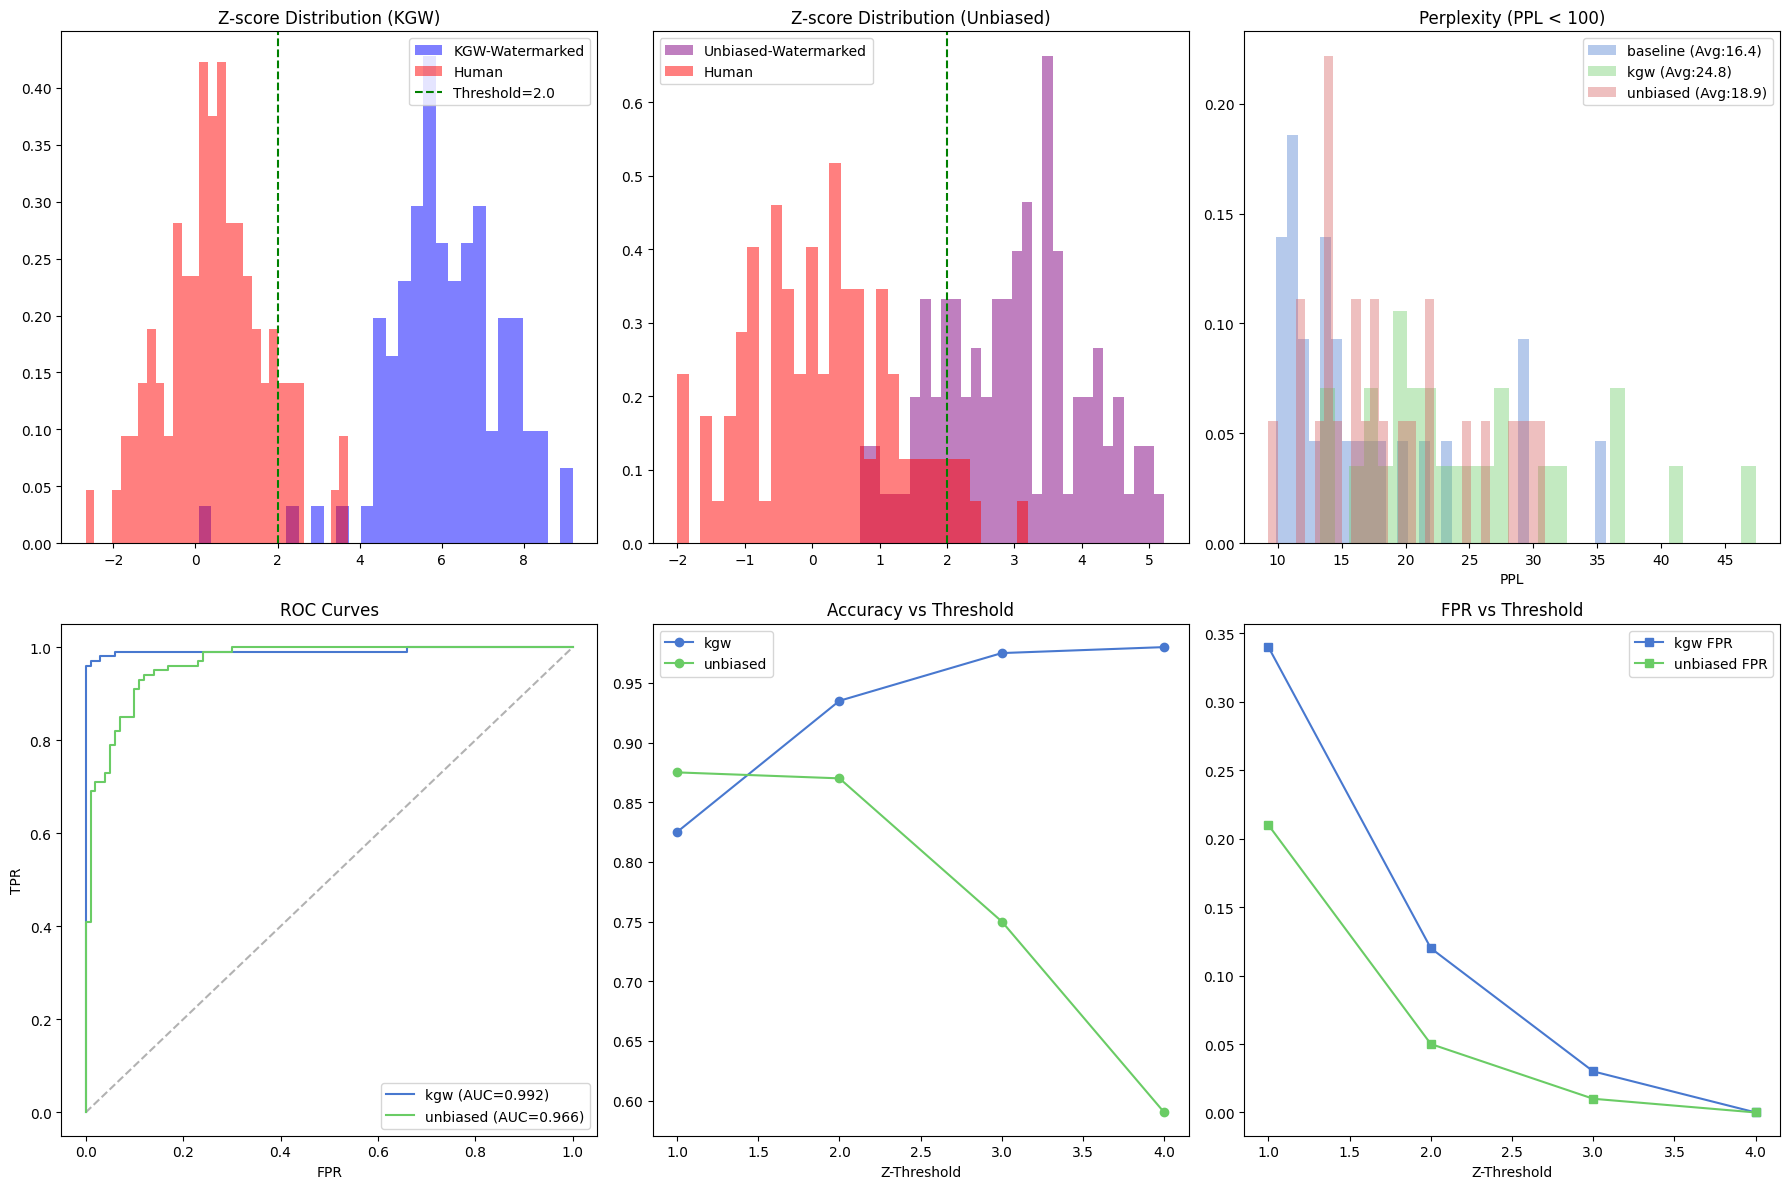

In [1]:
import torch
import numpy as np
import json
import pickle
import gc
import os
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, LogitsProcessor, LogitsProcessorList
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import hashlib

# ==========================================
# 0. 全局优化
# ==========================================
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:512"

# ==========================================
# 1. 核心工具函数
# ==========================================
def stable_hash(x):
    return int(hashlib.sha256(str(x).encode()).hexdigest(), 16) % (2**32)

def get_greenlist_mask(prev_tokens, vocab_size, gamma, hash_key, device):
    """
    统一的绿名单掩码生成逻辑，确保生成与检测严格对齐。
    """
    if isinstance(prev_tokens, torch.Tensor):
        prev_tokens = prev_tokens.cpu().tolist()
        
    # 使用 2-gram 上下文
    if len(prev_tokens) >= 2:
        context = tuple(prev_tokens[-2:])
    elif len(prev_tokens) == 1:
        context = (prev_tokens[-1],)
    else:
        context = (0,)
        
    seed = stable_hash((context, hash_key))
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)
    
    # 在指定设备上生成随机向量
    probs = torch.rand(vocab_size, generator=gen, device=device)
    return probs < gamma

# ==========================================
# 2. Watermark Processors
# ==========================================
class KGWLogitsProcessor(LogitsProcessor):
    def __init__(self, gamma=0.5, delta=2.0, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.delta = delta
        self.hash_key = hash_key
        self.device = device

    def __call__(self, input_ids, scores):
        vocab_size = scores.shape[-1]
        for b in range(input_ids.shape[0]):
            # KGW 默认通常使用 1-gram (上一个 token)
            prev_tokens = input_ids[b, -1:] 
            mask = get_greenlist_mask(prev_tokens, vocab_size, self.gamma, self.hash_key, self.device)
            scores[b][mask] += self.delta
        return scores

class UnbiasedLogitsProcessor(LogitsProcessor):
    def __init__(self, gamma=0.5, alpha=1.5, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.alpha = alpha
        self.hash_key = hash_key
        self.device = device

    def __call__(self, input_ids, scores):
        vocab_size = scores.shape[-1]
        for b in range(input_ids.shape[0]):
            probs = torch.softmax(scores[b], dim=-1)
            mask = get_greenlist_mask(input_ids[b], vocab_size, self.gamma, self.hash_key, self.device)
            
            p_green = probs[mask].sum()
            if p_green < 1e-6 or p_green > 0.999: continue 
            
            new_probs = probs.clone()
            new_probs[mask] *= self.alpha
            new_probs /= new_probs.sum()
            
            scores[b] = torch.log(new_probs.clamp(min=1e-10))
        return scores

# ==========================================
# 3. Detectors
# ==========================================
class KGWDetector:
    def __init__(self, tokenizer, gamma=0.5, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.hash_key = hash_key
        self.vocab_size = len(tokenizer)
        self.device = device

    def detect(self, tokens, prompt_len):
        if isinstance(tokens, list): tokens = torch.tensor(tokens)
        gen_len = len(tokens) - prompt_len
        if gen_len <= 5: return 0.0

        green_count = 0
        for i in range(prompt_len, len(tokens)):
            prev_tokens = tokens[i-1:i]
            cur = tokens[i].item()
            mask = get_greenlist_mask(prev_tokens, self.vocab_size, self.gamma, self.hash_key, self.device)
            if cur < self.vocab_size and mask[cur]:
                green_count += 1

        expected = self.gamma * gen_len
        var = gen_len * self.gamma * (1 - self.gamma)
        z = (green_count - expected) / (np.sqrt(var) + 1e-6)
        return float(z)

class UnbiasedDetector:
    def __init__(self, tokenizer, gamma=0.5, hash_key=42, device="cpu"):
        self.gamma = gamma
        self.hash_key = hash_key
        self.vocab_size = len(tokenizer)
        self.device = device

    def detect(self, tokens, prompt_len):
        if isinstance(tokens, list): tokens = torch.tensor(tokens)
        tokens = tokens.to(self.device)
        gen_len = len(tokens) - prompt_len
        if gen_len <= 5: return 0.0

        green_count = 0
        for i in range(prompt_len, len(tokens)):
            prev_context = tokens[:i]
            cur = tokens[i].item()
            mask = get_greenlist_mask(prev_context, self.vocab_size, self.gamma, self.hash_key, self.device)
            if cur < self.vocab_size and mask[cur]:
                green_count += 1

        expected = self.gamma * gen_len
        var = gen_len * self.gamma * (1 - self.gamma)
        z = (green_count - expected) / (np.sqrt(var) + 1e-6)
        return float(z)

# ==========================================
# 4. Engine & Evaluator (保持原有逻辑，确保 PPL 计算正确)
# ==========================================
class WatermarkEngine:
    def __init__(self, model, tokenizer, device):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device

    @torch.no_grad()
    def generate(self, prompts, processors, gen_config, batch_size=4):
        results = []
        for i in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
            batch_prompts = prompts[i:i+batch_size]
            inputs = self.tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(self.device)
            prompt_lens = (inputs.input_ids != self.tokenizer.pad_token_id).sum(dim=1)
            
            outputs = {"baseline": self.model.generate(**inputs, **gen_config)}
            for name, proc in processors.items():
                outputs[name] = self.model.generate(**inputs, logits_processor=LogitsProcessorList([proc]), **gen_config)

            for b in range(len(batch_prompts)):
                results.append({
                    "prompt_len": int(prompt_lens[b]),
                    "tokens": {k: v[b].cpu().tolist() for k, v in outputs.items()}
                })
            del inputs, outputs
            torch.cuda.empty_cache()
        return results

class Evaluator:
    def __init__(self, detectors, model, tokenizer):
        self.detectors = detectors
        self.model = model
        self.tokenizer = tokenizer

    def calc_ppl_batch(self, texts, max_batch=4):
        all_ppls = []
        for i in range(0, len(texts), max_batch):
            batch = [t for t in texts[i:i+max_batch] if len(t.strip()) > 0]
            if not batch: continue
            inputs = self.tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(self.model.device)
            with torch.no_grad():
                outputs = self.model(**inputs, labels=inputs["input_ids"])
            all_ppls.extend(torch.exp(outputs.loss).repeat(len(batch)).cpu().tolist())
        return all_ppls

    def evaluate(self, data, human, thresholds=[1.0, 2.0, 3.0, 4.0]):
        results = {
            "z_scores": {"baseline": [], "kgw": [], "unbiased": []},
            "ppl": {"baseline": [], "kgw": [], "unbiased": []},
            "human_z": {name: [] for name in self.detectors.keys()},
            "metrics": {}
        }
        
        # Z-scores
        print("Computing Z-scores...")
        for item in tqdm(data):
            p_len = item["prompt_len"]
            for name in results["z_scores"]:
                det = self.detectors.get(name, self.detectors["baseline"])
                results["z_scores"][name].append(det.detect(item["tokens"][name], p_len))

        # Human Z-scores
        print("Computing human Z-scores...")
        for txt in tqdm(human):
            tokens = self.tokenizer.encode(txt, return_tensors="pt")[0]
            for name, det in self.detectors.items():
                results["human_z"][name].append(det.detect(tokens, 0))

        # PPL
        print("Computing PPL...")
        for name in results["ppl"]:
            texts = [self.tokenizer.decode(item["tokens"][name][item["prompt_len"]:], skip_special_tokens=True) for item in data]
            results["ppl"][name] = self.calc_ppl_batch(texts)

        # Metrics
        for t in thresholds:
            results["metrics"][t] = {}
            for wm in ["kgw", "unbiased"]:
                wm_z = np.array(results["z_scores"][wm])
                hum_z = np.array(results["human_z"][wm])
                
                y_true = np.concatenate([np.ones(len(wm_z)), np.zeros(len(hum_z))])
                y_pred = np.concatenate([(wm_z > t).astype(int), (hum_z > t).astype(int)])
                
                # 补充缺失的指标计算
                results["metrics"][t][wm] = {
                    "accuracy": accuracy_score(y_true, y_pred),
                    "precision": precision_score(y_true, y_pred, zero_division=0), # 补充
                    "recall": recall_score(y_true, y_pred, zero_division=0),
                    "f1": f1_score(y_true, y_pred, zero_division=0),              # 补充
                    "fpr": np.sum(hum_z > t) / len(hum_z) if len(hum_z) > 0 else 0
                }
        return results

def plot_comprehensive_results(results, save_path="watermark_evaluation.png"):
    # 设置样式
    plt.style.use('seaborn-v0_8-muted') # 或者用 'ggplot'
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    z_dict = results["z_scores"]
    z_human = results["human_z"]
    ppl_dict = results["ppl"]
    metrics = results["metrics"]
    
    # 1. Z-score 分布（KGW 检测器）
    ax = axes[0, 0]
    ax.hist(z_dict["kgw"], bins=30, alpha=0.5, label="KGW-Watermarked", color='blue', density=True)
    if "kgw" in z_human:
        ax.hist(z_human["kgw"], bins=30, alpha=0.5, label="Human", color='red', density=True)
    ax.axvline(x=2, color='green', linestyle='--', label="Threshold=2.0")
    ax.set_title("Z-score Distribution (KGW)")
    ax.legend()
    
    # 2. Z-score 分布（Unbiased 检测器）
    ax = axes[0, 1]
    ax.hist(z_dict["unbiased"], bins=30, alpha=0.5, label="Unbiased-Watermarked", color='purple', density=True)
    if "unbiased" in z_human:
        ax.hist(z_human["unbiased"], bins=30, alpha=0.5, label="Human", color='red', density=True)
    ax.axvline(x=2, color='green', linestyle='--')
    ax.set_title("Z-score Distribution (Unbiased)")
    ax.legend()
    
    # 3. PPL 分布（限制范围以便观察）
    ax = axes[0, 2]
    for k, v in ppl_dict.items():
        if len(v) > 0:
            # 过滤掉 PPL 过大的离群点以便画图
            clean_v = [x for x in v if x < 100]
            ax.hist(clean_v, bins=30, alpha=0.4, label=f"{k} (Avg:{np.mean(v):.1f})", density=True)
    ax.set_title("Perplexity (PPL < 100)")
    ax.set_xlabel("PPL")
    ax.legend()
    
    # 4. ROC 曲线
    ax = axes[1, 0]
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    for wm_name in ["kgw", "unbiased"]:
        if wm_name in z_dict and wm_name in z_human:
            y_true = np.concatenate([np.ones(len(z_dict[wm_name])), np.zeros(len(z_human[wm_name]))])
            y_score = np.concatenate([z_dict[wm_name], z_human[wm_name]])
            fpr, tpr, _ = roc_curve(y_true, y_score)
            ax.plot(fpr, tpr, label=f"{wm_name} (AUC={auc(fpr, tpr):.3f})")
    ax.set_title("ROC Curves")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    
    # 5. 准确率 vs 阈值
    ax = axes[1, 1]
    if metrics:
        thresholds = sorted(metrics.keys())
        for wm_name in ["kgw", "unbiased"]:
            accs = [metrics[t][wm_name]["accuracy"] for t in thresholds if wm_name in metrics[t]]
            ax.plot(thresholds, accs, marker='o', label=wm_name)
    ax.set_title("Accuracy vs Threshold")
    ax.set_xlabel("Z-Threshold")
    ax.legend()
    
    # 6. 误报率 (FPR) vs 阈值
    ax = axes[1, 2]
    if metrics:
        thresholds = sorted(metrics.keys())
        for wm_name in ["kgw", "unbiased"]:
            fprs = [metrics[t][wm_name]["fpr"] for t in thresholds if wm_name in metrics[t]]
            ax.plot(thresholds, fprs, marker='s', label=f"{wm_name} FPR")
    ax.set_title("FPR vs Threshold")
    ax.set_xlabel("Z-Threshold")
    ax.legend()
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
        print(f"Comprehensive plot saved to {save_path}")
    plt.show()


def print_evaluation_report(results):
    """打印详细的评估报告"""
    print("\n" + "=" * 70)
    print("                    水印系统评估报告")
    print("=" * 70)
    
    z_dict = results["z_scores"]
    ppl_dict = results["ppl"]
    
    # 1. Z-score 统计
    print("\n【1. Z-score 统计】")
    print("-" * 50)
    print(f"{'类型':<12} {'均值':>8} {'标准差':>8} {'样本数':>8}")
    print("-" * 50)
    for name in ["baseline", "kgw", "unbiased"]:
        z_scores = z_dict[name]
        print(f"{name:<12} {np.mean(z_scores):>8.3f} {np.std(z_scores):>8.3f} {len(z_scores):>8}")
    
    print("\n【Human Z-score (各检测器)】")
    print("-" * 50)
    for det_name, z_scores in results["human_z"].items():
        print(f"{det_name:<12} {np.mean(z_scores):>8.3f} {np.std(z_scores):>8.3f} {len(z_scores):>8}")
    
    # 2. 困惑度统计
    print("\n【2. 文本困惑度 (PPL)】")
    print("-" * 50)
    print(f"{'类型':<12} {'均值':>8} {'标准差':>8} {'相对提升':>10}")
    print("-" * 50)
    baseline_ppl = np.mean(ppl_dict["baseline"])
    for name in ["baseline", "kgw", "unbiased"]:
        ppls = ppl_dict[name]
        mean_ppl = np.mean(ppls)
        relative = ((mean_ppl / baseline_ppl - 1) * 100) if name != "baseline" else 0
        print(f"{name:<12} {mean_ppl:>8.2f} {np.std(ppls):>8.2f} {relative:>9.1f}%")
    
    # 3. 检测性能（推荐阈值=2）
    print("\n【3. 检测性能 (阈值=2.0)】")
    print("-" * 70)
    print(f"{'水印类型':<10} {'准确率':>8} {'精确率':>8} {'召回率':>8} {'F1':>8} {'误报率':>8}")
    print("-" * 70)
    
    if 2.0 in results["metrics"]:
        for wm_name in ["kgw", "unbiased"]:
            if wm_name not in results["metrics"][2.0]:
                continue
            m = results["metrics"][2.0][wm_name]
            print(f"{wm_name:<10} {m['accuracy']:>8.3f} {m['precision']:>8.3f} "
                  f"{m['recall']:>8.3f} {m['f1']:>8.3f} {m['fpr']:>8.3f}")
    
    # 4. 多阈值对比
    print("\n【4. 多阈值检测性能对比】")
    print("-" * 70)
    for threshold in sorted(results["metrics"].keys()):
        print(f"\n阈值 = {threshold}:")
        for wm_name in ["kgw", "unbiased"]:
            if wm_name not in results["metrics"][threshold]:
                continue
            m = results["metrics"][threshold][wm_name]
            print(f"  {wm_name}: 准确率={m['accuracy']:.3f}, 误报率={m['fpr']:.3f}, 召回率={m['recall']:.3f}")
    
    # 5. 结论
    print("\n" + "=" * 70)
    print("【5. 评估结论】")
    print("=" * 70)
    
    # KGW 评估
    kgw_z = np.array(z_dict["kgw"])
    kgw_detected = np.sum(kgw_z > 2) / len(kgw_z) * 100
    print(f"\n✓ KGW 水印:")
    print(f"  - 检测成功率 (Z>2): {kgw_detected:.1f}%")
    print(f"  - 平均 Z-score: {np.mean(kgw_z):.2f}")
    print(f"  - 质量损失: {((np.mean(ppl_dict['kgw']) / baseline_ppl - 1) * 100):.1f}%")
    
    # Unbiased 评估
    unbiased_z = np.array(z_dict["unbiased"])
    unbiased_detected = np.sum(unbiased_z > 2) / len(unbiased_z) * 100
    print(f"\n✓ Unbiased 水印:")
    print(f"  - 检测成功率 (Z>2): {unbiased_detected:.1f}%")
    print(f"  - 平均 Z-score: {np.mean(unbiased_z):.2f}")
    print(f"  - 质量损失: {((np.mean(ppl_dict['unbiased']) / baseline_ppl - 1) * 100):.1f}%")
# ==========================================
# 5. Main Execution
# ==========================================
def main():
    device = "cuda"
    model_small = "/root/autodl-tmp/Qwen2.5-1.5B-Instruct"
    model_large = "/root/autodl-tmp/Qwen2.5-7B-Instruct"
    
    # 加载 prompts 和 human_texts
    print("Loading data files...")
    with open("prompts.json", 'r', encoding='utf-8') as f:
        prompts_data = json.load(f)
        prompts = prompts_data["test_prompts"]
    
    with open("human_texts.json", 'r', encoding='utf-8') as f:
        human_data = json.load(f)
        human = human_data["human_texts"]

    tokenizer1 = AutoTokenizer.from_pretrained(model_small)
    tokenizer1.pad_token = tokenizer1.eos_token
    tokenizer1.padding_side = "left"
    model1 = AutoModelForCausalLM.from_pretrained(model_small, torch_dtype=torch.float16).to(device)
    
    processors = {
        "kgw": KGWLogitsProcessor(gamma=0.5, delta=2.0, device=device),
        "unbiased": UnbiasedLogitsProcessor(gamma=0.5, alpha=2.5, device=device),
    }
    
    gen_config = {
        "max_new_tokens": 128,
        "do_sample": True,
        "temperature": 1.0, # 无偏水印建议设为 1.0
        "top_p": 1.0,       # 关闭截断以保证统计分布完整
        "pad_token_id": tokenizer1.pad_token_id,
    }
    
    engine = WatermarkEngine(model1, tokenizer1, device)
    data = engine.generate(prompts, processors, gen_config)
    
    # 切换到 7B 模型评估
    del model1
    torch.cuda.empty_cache()
    
    model2 = AutoModelForCausalLM.from_pretrained(model_large, torch_dtype=torch.float16).to(device)
    tokenizer2 = AutoTokenizer.from_pretrained(model_large)
    tokenizer2.pad_token = tokenizer2.eos_token
    
    detectors = {
        "baseline": KGWDetector(tokenizer1, gamma=0.5, device=device),
        "kgw": KGWDetector(tokenizer1, gamma=0.5, device=device),
        "unbiased": UnbiasedDetector(tokenizer1, gamma=0.5, device=device),
    }
    
    evaluator = Evaluator(detectors, model2, tokenizer2)
    results = evaluator.evaluate(data, human)
    
    # 打印结果 (使用你原有的 print_evaluation_report 函数)
    print_evaluation_report(results)
    plot_comprehensive_results(results, save_path="watermark_analysis_final.png")
if __name__ == "__main__":
    main()